Daisyworld: динамика количества ромашек

В этом скрипте моделируется система Daisyworld и
анализируется изменение количества черных и белых
ромашек во времени.

## Подключение пакетов и активация проекта

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))

using DrWatson
@quickactivate "project"

using Agents
using DataFrames
using Plots
using CairoMakie

  Activating project at `~/work/study/2026--1/2026-1-study-simulation-modeling/labs/lab03/project`


## Подключение реализации модели

In [2]:
include(srcdir("daisyworld.jl"))

  Activating project at `~/work/study/2026--1/2026-1-study-simulation-modeling/labs/lab03/project`


daisyworld (generic function with 1 method)

## Определение типов агентов

В модели есть два типа ромашек:
- черные (black)
- белые (white)

In [3]:
black(a) = a.breed == :black
white(a) = a.breed == :white

white (generic function with 1 method)

Будем считать количество агентов каждого типа

In [4]:
adata = [(black, count), (white, count)]

2-element Vector{Tuple{Function, typeof(count)}}:
 (Main.black, count)
 (Main.white, count)

## Создание модели

Параметр solar_luminosity задаёт интенсивность
солнечного излучения.

In [5]:
model = daisyworld(; solar_luminosity = 1.0)

StandardABM with 360 agents of type Daisy
 agents container: Dict
 space: GridSpaceSingle with size (30, 30), metric=chebyshev, periodic=true
 scheduler: fastest
 properties: temperature, solar_luminosity, max_age, surface_albedo, ratio, solar_change, tick, scenario

## Запуск симуляции

Функция run! выполняет модель в течение заданного
числа шагов и собирает статистику.

In [6]:
agent_df, model_df = run!(model, 1000; adata)

(1001×3 DataFrame
  Row │ time   count_black  count_white 
      │ Int64  Int64        Int64       
──────┼─────────────────────────────────
    1 │     0          180          180
    2 │     1          399          171
    3 │     2          558          225
    4 │     3          588          279
    5 │     4          594          301
    6 │     5          588          309
    7 │     6          583          313
    8 │     7          578          319
    9 │     8          573          323
   10 │     9          567          333
   11 │    10          567          333
  ⋮   │   ⋮         ⋮            ⋮
  992 │   991          512          386
  993 │   992          508          390
  994 │   993          506          391
  995 │   994          508          390
  996 │   995          509          387
  997 │   996          502          395
  998 │   997          505          395
  999 │   998          512          388
 1000 │   999          518          381
 1001 │  1000          5

agent_df содержит данные о количестве ромашек
каждого типа на каждом шаге модели.

## Построение графика

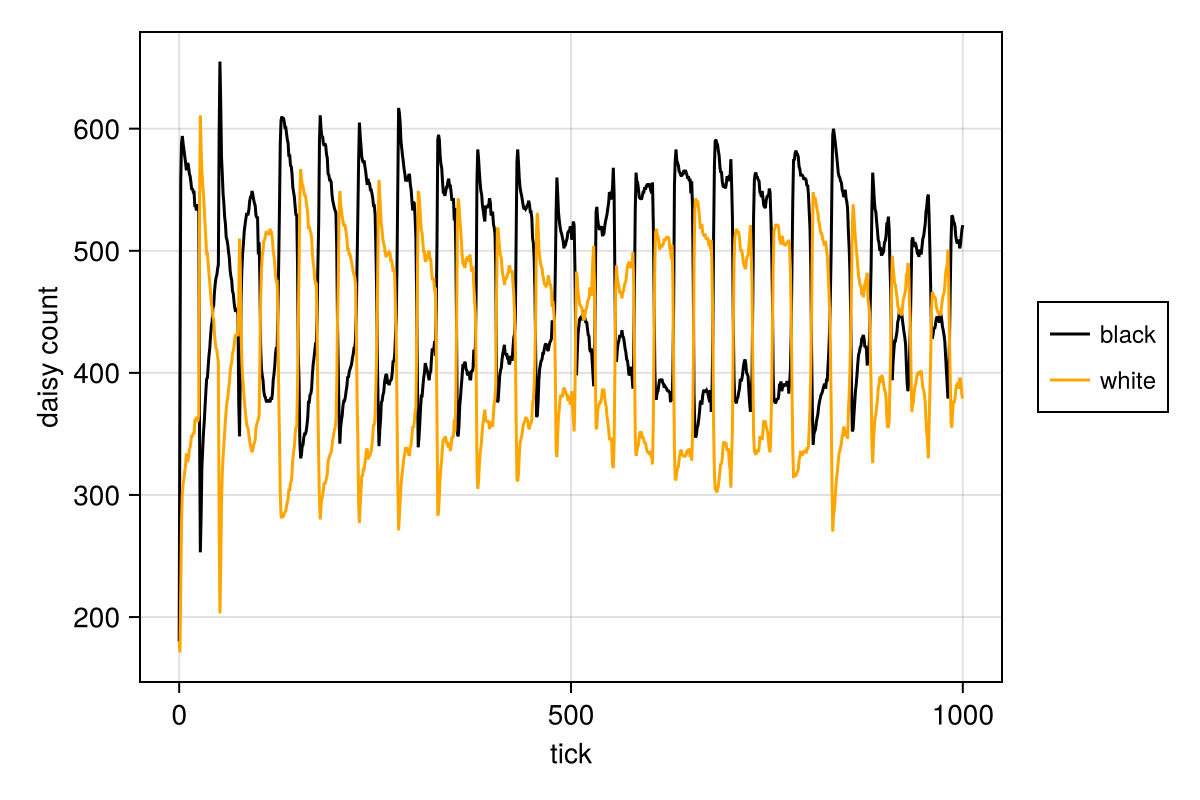

In [7]:
figure = Figure(size = (600, 400))

ax = figure[1, 1] = Axis(
    figure,
    xlabel = "tick",
    ylabel = "daisy count"
)

blackl = lines!(
    ax,
    agent_df[!, :time],
    agent_df[!, :count_black],
    color = :black
)

whitel = lines!(
    ax,
    agent_df[!, :time],
    agent_df[!, :count_white],
    color = :orange
)

Legend(
    figure[1, 2],
    [blackl, whitel],
    ["black", "white"],
    labelsize = 12
)

figure

## Сохранение результата

In [8]:
save(plotsdir("daisy_count.png"), figure)

## Анализ

График показывает изменение количества черных и белых
ромашек во времени. В зависимости от температуры среды
один из типов может иметь преимущество в размножении.

Поскольку разные типы ромашек имеют различное альбедо,
их распространение влияет на температуру поверхности.
Это приводит к обратной связи между растительностью
и климатом.

Модель демонстрирует механизм саморегуляции:
изменение численности растений способствует
стабилизации температурных условий.